In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

ANNOTATION_DIR = "/kaggle/input/datasets/iftekharuddin27/annotated-data"   
OUTPUT_DIR     = "/kaggle/working/"

CLASS_NAMES_EN = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
CLASS_NAMES_BN = {0: 'Not Hateful', 1: 'Explicit Hateful', 2: 'Implicit Hateful'}

print("Imports loaded.")

Imports loaded.


In [16]:
# ============================================================
# Load and normalize annotations
# ============================================================
en_raw = pd.read_csv("/kaggle/input/datasets/iftekharuddin27/annotated-data/English Annotation - English_balanced_1k_cleaned.csv")
bn_raw = pd.read_csv("/kaggle/input/datasets/iftekharuddin27/annotated-data/Bangla Annotation - bangla_hate_speech_1k.csv")

# ── Normalize functions ──────────────────────────────────────
def norm_sarcasm(v):
    if pd.isna(v): return 'none'
    v = str(v).strip().lower()
    if 'sarcasm' in v: return 'sarcasm'
    if 'humor'   in v: return 'humor'
    if 'irony'   in v: return 'irony'
    if 'metaphor' in v: return 'metaphor'
    return 'none'

def norm_hate(v):
    if pd.isna(v): return 'none'
    v = str(v).strip().lower().replace('-','_').replace(' ','_')
    if 'non' in v or 'not' in v: return 'non_hateful'
    if 'abusive'   in v: return 'abusive'
    if 'offensive' in v: return 'offensive'
    if 'hate'      in v: return 'hate_speech'
    return 'none'

# ── English ──────────────────────────────────────────────────
en = en_raw.copy()
en = en.rename(columns={'class': 'original_label'})
en['label_name']         = en['original_label'].map(CLASS_NAMES_EN)
en['sarcasm_type_clean'] = en['sarcasm_type'].apply(norm_sarcasm)
en['hate_type_clean']    = en['hate_type'].apply(norm_hate)

# Binary annotation axes
en['is_sarcastic'] = (en['sarcasm_type_clean'] != 'none').astype(int)
en['is_hateful']   = (en['hate_type_clean'].isin(['abusive','offensive','hate_speech'])).astype(int)

# ── Bangla ───────────────────────────────────────────────────
bn = bn_raw.copy()
bn['sarcasm_type_clean'] = bn['sarcasm_type'].apply(norm_sarcasm)
bn['hate_type_clean']    = bn['hate_type'].apply(norm_hate)
bn['is_sarcastic'] = (bn['sarcasm_type_clean'] != 'none').astype(int)
bn['is_hateful']   = (bn['hate_type_clean'].isin(['abusive','offensive','hate_speech'])).astype(int)

print(f"English cleaned: {len(en)} rows")
print(f"Bangla  cleaned: {len(bn)} rows")
print("\nEnglish sarcasm_type_clean:\n", en['sarcasm_type_clean'].value_counts())
print("\nEnglish hate_type_clean:\n",    en['hate_type_clean'].value_counts())
print("\nBangla  sarcasm_type_clean:\n", bn['sarcasm_type_clean'].value_counts())
print("\nBangla  hate_type_clean:\n",    bn['hate_type_clean'].value_counts())

en.to_csv(f"{OUTPUT_DIR}english_annotation_clean.csv", index=False)
bn.to_csv(f"{OUTPUT_DIR}bangla_annotation_clean.csv",  index=False)

English cleaned: 999 rows
Bangla  cleaned: 999 rows

English sarcasm_type_clean:
 sarcasm_type_clean
none        681
sarcasm     205
humor        87
irony        21
metaphor      5
Name: count, dtype: int64

English hate_type_clean:
 hate_type_clean
non_hateful    542
offensive      165
abusive        149
none           106
hate_speech     37
Name: count, dtype: int64

Bangla  sarcasm_type_clean:
 sarcasm_type_clean
none        677
sarcasm     196
humor        84
irony        37
metaphor      5
Name: count, dtype: int64

Bangla  hate_type_clean:
 hate_type_clean
non_hateful    525
abusive        186
offensive      152
none           108
hate_speech     28
Name: count, dtype: int64


In [17]:
# ============================================================
# Annotation Consistency Analysis 
# ============================================================
# Since raw per-annotator labels are unavailable, we measure
# internal consistency: how consistently each class was annotated.

def annotation_consistency(df, label_col, sarcasm_col, hate_col, dataset_name):
    print(f"\n{'='*60}")
    print(f"Annotation Consistency — {dataset_name}")
    print(f"{'='*60}")

    # For each original class, what % of texts got sarcasm annotated?
    print("\nSarcasm annotation rate by original class:")
    sarc_rate = df.groupby(label_col)['is_sarcastic'].mean()
    for cls, rate in sarc_rate.items():
        print(f"  Class {cls}: {rate*100:.1f}% annotated as sarcastic")

    # For each original class, what % got hate annotated?
    print("\nHate annotation rate by original class:")
    hate_rate = df.groupby(label_col)['is_hateful'].mean()
    for cls, rate in hate_rate.items():
        print(f"  Class {cls}: {rate*100:.1f}% annotated as hateful")

    # Cross-tab: original label vs annotated sarcasm
    print("\nOriginal label vs is_sarcastic:")
    print(pd.crosstab(df[label_col], df['is_sarcastic'],
                      rownames=['Original'], colnames=['Annotated Sarcastic'],
                      normalize='index').round(3))

    # Cross-tab: original label vs annotated hate
    print("\nOriginal label vs is_hateful:")
    print(pd.crosstab(df[label_col], df['is_hateful'],
                      rownames=['Original'], colnames=['Annotated Hateful'],
                      normalize='index').round(3))

annotation_consistency(en, 'original_label', 'sarcasm_type_clean', 'hate_type_clean', 'English')
annotation_consistency(bn, 'label',           'sarcasm_type_clean', 'hate_type_clean', 'Bangla')


Annotation Consistency — English

Sarcasm annotation rate by original class:
  Class 0: 3.5% annotated as sarcastic
  Class 1: 0.9% annotated as sarcastic
  Class 2: 93.8% annotated as sarcastic

Hate annotation rate by original class:
  Class 0: 4.1% annotated as hateful
  Class 1: 95.8% annotated as hateful
  Class 2: 4.6% annotated as hateful

Original label vs is_sarcastic:
Annotated Sarcastic      0      1
Original                         
0                    0.965  0.035
1                    0.991  0.009
2                    0.062  0.938

Original label vs is_hateful:
Annotated Hateful      0      1
Original                       
0                  0.959  0.041
1                  0.042  0.958
2                  0.954  0.046

Annotation Consistency — Bangla

Sarcasm annotation rate by original class:
  Class 0: 0.9% annotated as sarcastic
  Class 1: 0.3% annotated as sarcastic
  Class 2: 95.5% annotated as sarcastic

Hate annotation rate by original class:
  Class 0: 3.6% annot

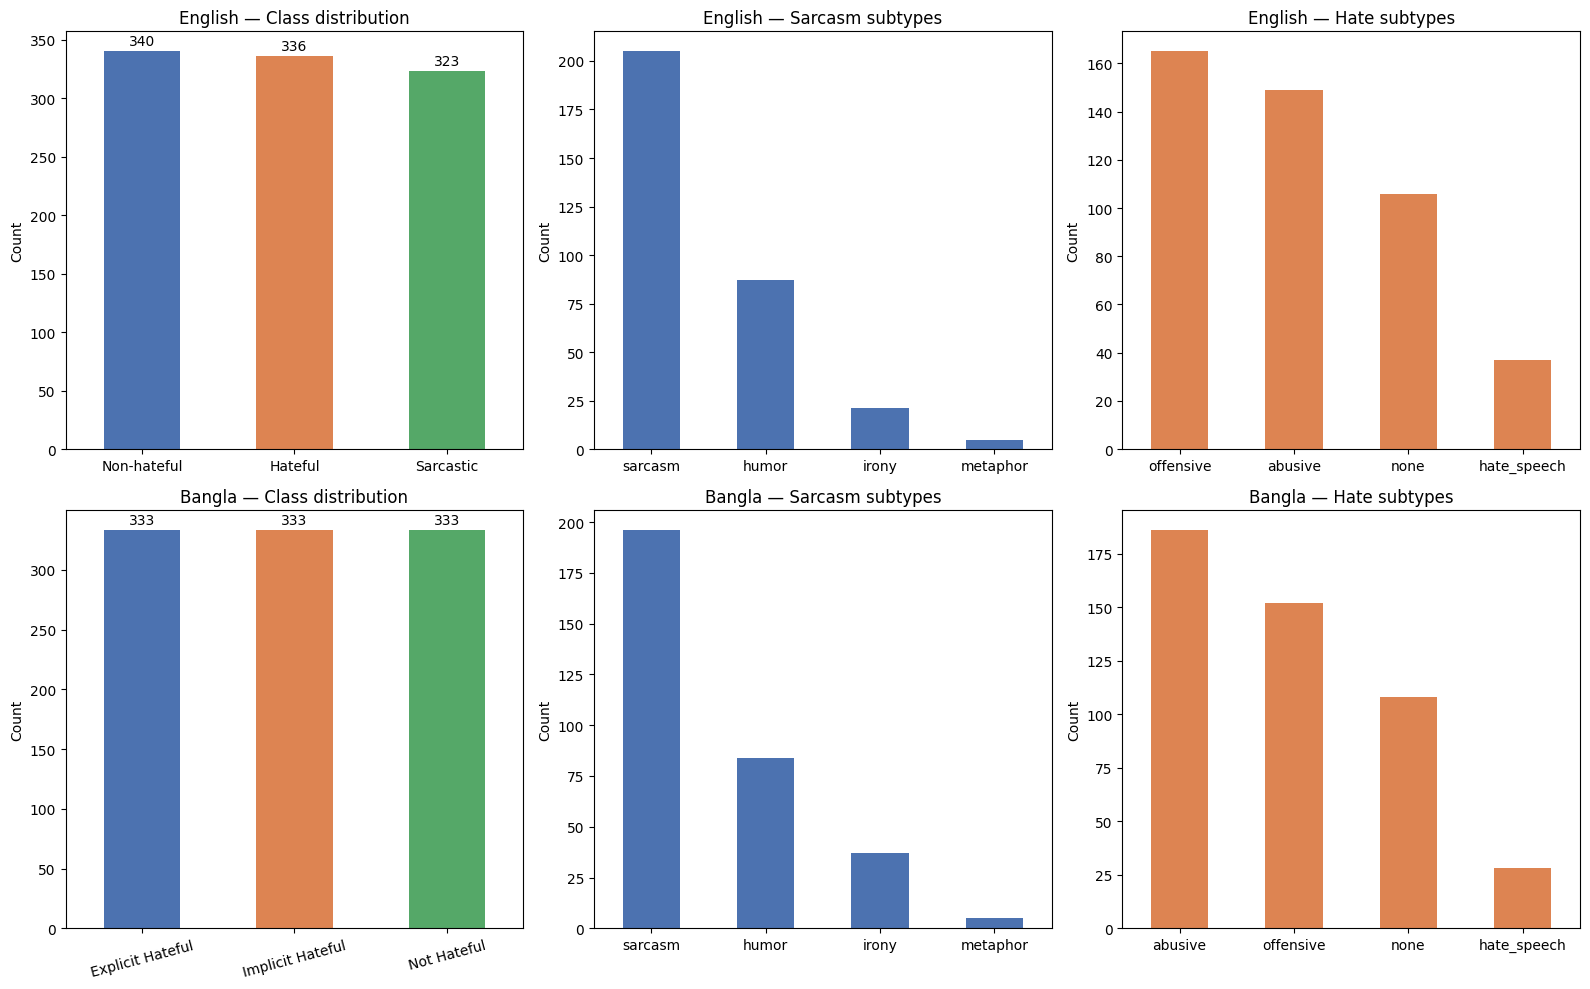

Saved: annotation_distributions.png


In [18]:
# ============================================================
#  Annotation distribution visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── English ──────────────────────────────────────────────────
# Plot 1: Class distribution
en['label_name'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#4C72B0','#DD8452','#55A868'], rot=0)
axes[0,0].set_title('English — Class distribution')
axes[0,0].set_xlabel(''); axes[0,0].set_ylabel('Count')
for p in axes[0,0].patches:
    axes[0,0].annotate(str(int(p.get_height())),
        (p.get_x()+p.get_width()/2, p.get_height()+5), ha='center', fontsize=10)

# Plot 2: Sarcasm type distribution
en_sarc = en[en['sarcasm_type_clean'] != 'none']['sarcasm_type_clean'].value_counts()
en_sarc.plot(kind='bar', ax=axes[0,1], color='#4C72B0', rot=0)
axes[0,1].set_title('English — Sarcasm subtypes')
axes[0,1].set_xlabel(''); axes[0,1].set_ylabel('Count')

# Plot 3: Hate type distribution
en_hate = en[en['hate_type_clean'] != 'non_hateful']['hate_type_clean'].value_counts()
en_hate.plot(kind='bar', ax=axes[0,2], color='#DD8452', rot=0)
axes[0,2].set_title('English — Hate subtypes')
axes[0,2].set_xlabel(''); axes[0,2].set_ylabel('Count')

# ── Bangla ───────────────────────────────────────────────────
bn_label_map = {0:'Not Hateful', 1:'Explicit Hateful', 2:'Implicit Hateful'}
bn['label_name_plot'] = bn['label'].map(bn_label_map)

bn['label_name_plot'].value_counts().plot(
    kind='bar', ax=axes[1,0], color=['#4C72B0','#DD8452','#55A868'], rot=15)
axes[1,0].set_title('Bangla — Class distribution')
axes[1,0].set_xlabel(''); axes[1,0].set_ylabel('Count')
for p in axes[1,0].patches:
    axes[1,0].annotate(str(int(p.get_height())),
        (p.get_x()+p.get_width()/2, p.get_height()+5), ha='center', fontsize=10)

bn_sarc = bn[bn['sarcasm_type_clean'] != 'none']['sarcasm_type_clean'].value_counts()
bn_sarc.plot(kind='bar', ax=axes[1,1], color='#4C72B0', rot=0)
axes[1,1].set_title('Bangla — Sarcasm subtypes')
axes[1,1].set_xlabel(''); axes[1,1].set_ylabel('Count')

bn_hate = bn[bn['hate_type_clean'] != 'non_hateful']['hate_type_clean'].value_counts()
bn_hate.plot(kind='bar', ax=axes[1,2], color='#DD8452', rot=0)
axes[1,2].set_title('Bangla — Hate subtypes')
axes[1,2].set_xlabel(''); axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}annotation_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: annotation_distributions.png")


Sarcastic-Hate Overlap — English
  Sarcastic AND Hateful  : 8  (0.8%)  ← sarcasm as hate vehicle
  Sarcastic only         : 310  (31.0%)
  Hateful only           : 343  (34.3%)
  Neither                : 338  (33.8%)


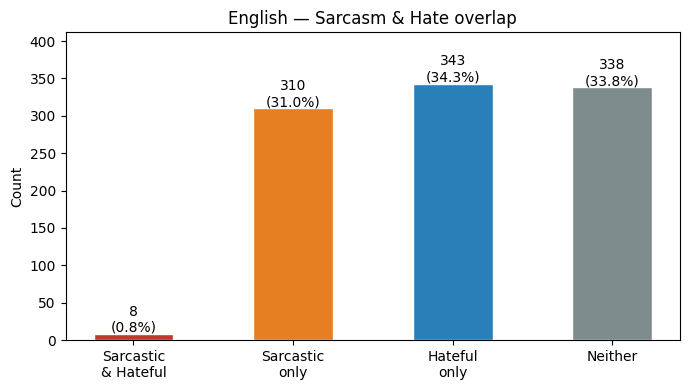


Sarcastic-Hate Overlap — Bangla
  Sarcastic AND Hateful  : 17  (1.7%)  ← sarcasm as hate vehicle
  Sarcastic only         : 305  (30.5%)
  Hateful only           : 349  (34.9%)
  Neither                : 328  (32.8%)


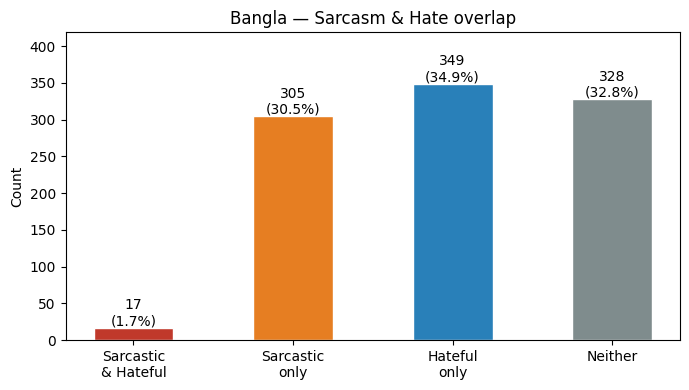

In [19]:
# ============================================================
# Sarcastic-Hate overlap analysis
# ============================================================

def sarcastic_hate_overlap(df, label_col, dataset_name):
    print(f"\n{'='*60}")
    print(f"Sarcastic-Hate Overlap — {dataset_name}")
    print(f"{'='*60}")

    total = len(df)
    both      = ((df['is_sarcastic']==1) & (df['is_hateful']==1)).sum()
    sarc_only = ((df['is_sarcastic']==1) & (df['is_hateful']==0)).sum()
    hate_only = ((df['is_sarcastic']==0) & (df['is_hateful']==1)).sum()
    neither   = ((df['is_sarcastic']==0) & (df['is_hateful']==0)).sum()

    print(f"  Sarcastic AND Hateful  : {both}  ({both/total*100:.1f}%)  ← sarcasm as hate vehicle")
    print(f"  Sarcastic only         : {sarc_only}  ({sarc_only/total*100:.1f}%)")
    print(f"  Hateful only           : {hate_only}  ({hate_only/total*100:.1f}%)")
    print(f"  Neither                : {neither}  ({neither/total*100:.1f}%)")

    # Venn-style bar chart
    fig, ax = plt.subplots(figsize=(7, 4))
    categories = ['Sarcastic\n& Hateful', 'Sarcastic\nonly', 'Hateful\nonly', 'Neither']
    counts     = [both, sarc_only, hate_only, neither]
    colors     = ['#c0392b','#e67e22','#2980b9','#7f8c8d']
    bars = ax.bar(categories, counts, color=colors, edgecolor='white', width=0.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                f'{count}\n({count/total*100:.1f}%)', ha='center', fontsize=10)
    ax.set_title(f'{dataset_name} — Sarcasm & Hate overlap')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts)*1.2)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}overlap_{dataset_name}.png", dpi=150)
    plt.show()

    return {'both': both, 'sarc_only': sarc_only,
            'hate_only': hate_only, 'neither': neither}

en_overlap = sarcastic_hate_overlap(en, 'original_label', 'English')
bn_overlap = sarcastic_hate_overlap(bn, 'label',           'Bangla')

In [21]:
import os

PRED_DIR = "/kaggle/input/datasets/iftekharuddin27/transformer-model-preds"  

# Load predictions
bert_preds       = np.load(f"{PRED_DIR}/test_preds_BERT_English.npy")
bert_probs       = np.load(f"{PRED_DIR}/test_probs_BERT_English.npy")
banglabert_preds = np.load(f"{PRED_DIR}/test_preds_BanglaBERT_Bangla.npy")
banglabert_probs = np.load(f"{PRED_DIR}/test_probs_BanglaBERT_Bangla.npy")

print(f"BERT English preds:       {bert_preds.shape}")
print(f"BanglaBERT Bangla preds:  {banglabert_preds.shape}")

# Load test sets (need text + true labels)
PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"
en_test = pd.read_csv(f"{PREPROCESSED_DIR}/en_test.csv")
bn_test = pd.read_csv(f"{PREPROCESSED_DIR}/bn_test.csv")
en_test['text_clean'] = en_test['text_clean'].fillna('')
bn_test['text_clean'] = bn_test['text_clean'].fillna('')

y_en_test = en_test['class'].values
y_bn_test = bn_test['label'].values

# Add predictions to test dataframes
en_test['pred']          = bert_preds
en_test['pred_name']     = pd.Series(bert_preds).map(CLASS_NAMES_EN)
en_test['true_name']     = pd.Series(y_en_test).map(CLASS_NAMES_EN)
en_test['correct']       = (bert_preds == y_en_test)
en_test['confidence']    = bert_probs.max(axis=1)

bn_test['pred']          = banglabert_preds
bn_test['pred_name']     = pd.Series(banglabert_preds).map(CLASS_NAMES_BN)
bn_test['true_name']     = pd.Series(y_bn_test).map(CLASS_NAMES_BN)
bn_test['correct']       = (banglabert_preds == y_bn_test)
bn_test['confidence']    = banglabert_probs.max(axis=1)

print(f"\nEnglish test accuracy: {en_test['correct'].mean():.4f}")
print(f"Bangla  test accuracy: {bn_test['correct'].mean():.4f}")

BERT English preds:       (10432,)
BanglaBERT Bangla preds:  (8377,)

English test accuracy: 0.9033
Bangla  test accuracy: 0.8316


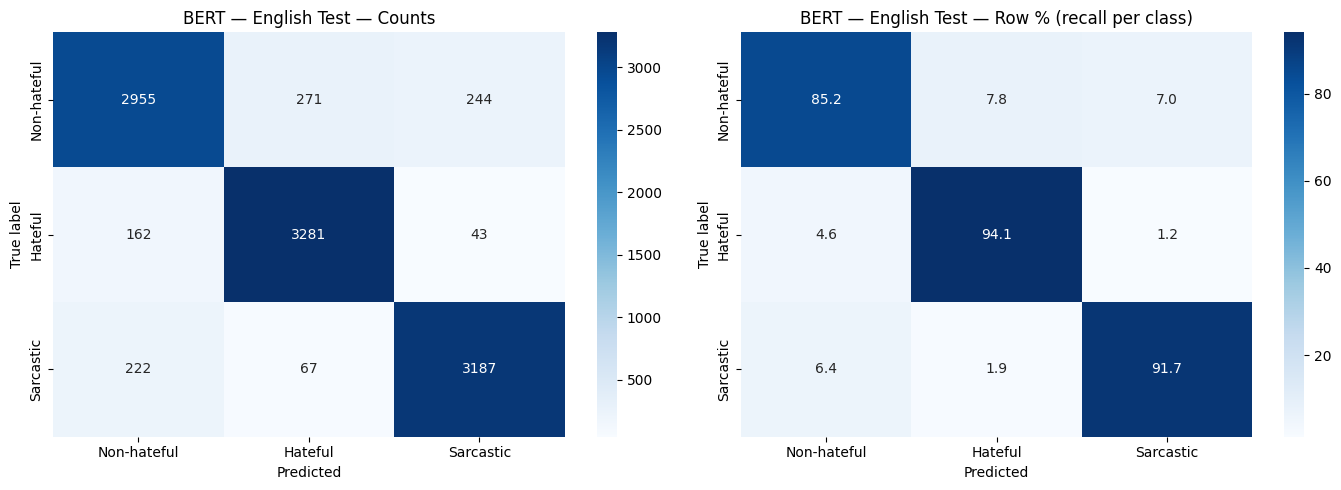


Key misclassification patterns — BERT — English Test:
  True=Non-hateful → Predicted=Hateful: 271 cases (7.8%)
  True=Non-hateful → Predicted=Sarcastic: 244 cases (7.0%)
  True=Hateful → Predicted=Non-hateful: 162 cases (4.6%)
  True=Hateful → Predicted=Sarcastic: 43 cases (1.2%)
  True=Sarcastic → Predicted=Non-hateful: 222 cases (6.4%)
  True=Sarcastic → Predicted=Hateful: 67 cases (1.9%)


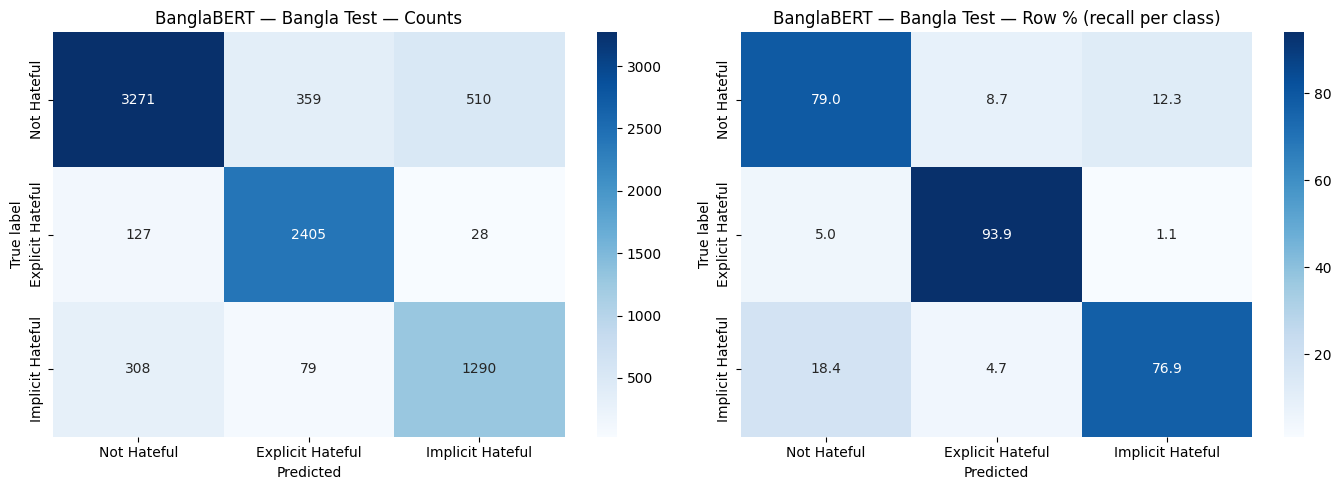


Key misclassification patterns — BanglaBERT — Bangla Test:
  True=Not Hateful → Predicted=Explicit Hateful: 359 cases (8.7%)
  True=Not Hateful → Predicted=Implicit Hateful: 510 cases (12.3%)
  True=Explicit Hateful → Predicted=Not Hateful: 127 cases (5.0%)
  True=Explicit Hateful → Predicted=Implicit Hateful: 28 cases (1.1%)
  True=Implicit Hateful → Predicted=Not Hateful: 308 cases (18.4%)
  True=Implicit Hateful → Predicted=Explicit Hateful: 79 cases (4.7%)


In [23]:
# ============================================================
#  Detailed confusion matrix on full test set
# ============================================================
def plot_confusion(y_true, y_pred, class_names, title, save_name):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names.values(),
                yticklabels=class_names.values(), ax=axes[0])
    axes[0].set_title(f'{title} — Counts')
    axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted')

    # Row-normalized percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names.values(),
                yticklabels=class_names.values(), ax=axes[1])
    axes[1].set_title(f'{title} — Row % (recall per class)')
    axes[1].set_ylabel('True label'); axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}{save_name}.png", dpi=150)
    plt.show()

    # Print what the errors mean
    print(f"\nKey misclassification patterns — {title}:")
    classes = list(class_names.values())
    for i, true_cls in enumerate(classes):
        for j, pred_cls in enumerate(classes):
            if i != j and cm[i,j] > 0:
                print(f"  True={true_cls} → Predicted={pred_cls}: "
                      f"{cm[i,j]} cases ({cm_pct[i,j]:.1f}%)")

plot_confusion(y_en_test, bert_preds, CLASS_NAMES_EN,
               'BERT — English Test', 'cm_bert_english_test')
plot_confusion(y_bn_test, banglabert_preds, CLASS_NAMES_BN,
               'BanglaBERT — Bangla Test', 'cm_banglabert_bangla_test')

In [31]:
# ============================================================
# Use full test set for error analysis
# ============================================================


print(f"English test set: {len(en_test)} texts")
print(f"Bangla  test set: {len(bn_test)} texts")

# Still try to merge annotated data for annotation-specific analysis
en_merged = en.merge(
    en_test[['text_clean','pred','pred_name','correct','confidence']],
    left_on='text', right_on='text_clean', how='inner'
)
bn_merged = bn.merge(
    bn_test[['text_clean','pred','pred_name','correct','confidence']],
    left_on='text', right_on='text_clean', how='inner'
)
print(f"\nAnnotated texts matched in test set: EN={len(en_merged)}, BN={len(bn_merged)}")
print("(Small overlap is expected — annotation sampled from full dataset)")
print("\nUsing FULL test set for main error analysis.")

English test set: 10432 texts
Bangla  test set: 8377 texts

Annotated texts matched in test set: EN=20, BN=37
(Small overlap is expected — annotation sampled from full dataset)

Using FULL test set for main error analysis.


In [32]:
# ============================================================
#  Error breakdown by annotation type
# ============================================================
def error_breakdown(df_merged, dataset_name, label_col):
    print(f"\n{'='*60}")
    print(f"Error breakdown — {dataset_name}")
    print(f"{'='*60}")

    errors = df_merged[~df_merged['correct']]
    correct = df_merged[df_merged['correct']]

    print(f"\nTotal matched: {len(df_merged)}")
    print(f"Correct: {len(correct)} ({len(correct)/len(df_merged)*100:.1f}%)")
    print(f"Errors:  {len(errors)} ({len(errors)/len(df_merged)*100:.1f}%)")

    if len(errors) == 0:
        print("No errors found in matched set.")
        return

    # Error rate by sarcasm type
    print("\nError rate by sarcasm_type:")
    sarc_err = df_merged.groupby('sarcasm_type_clean')['correct'].agg(
        total='count', correct='sum')
    sarc_err['error_rate'] = 1 - sarc_err['correct'] / sarc_err['total']
    print(sarc_err.sort_values('error_rate', ascending=False).round(3))

    # Error rate by hate type
    print("\nError rate by hate_type:")
    hate_err = df_merged.groupby('hate_type_clean')['correct'].agg(
        total='count', correct='sum')
    hate_err['error_rate'] = 1 - hate_err['correct'] / hate_err['total']
    print(hate_err.sort_values('error_rate', ascending=False).round(3))

    # Sarcastic-hate texts: how often does model fail?
    both_mask = (df_merged['is_sarcastic']==1) & (df_merged['is_hateful']==1)
    if both_mask.sum() > 0:
        both_acc = df_merged[both_mask]['correct'].mean()
        print(f"\nModel accuracy on 'sarcastic AND hateful' texts: {both_acc*100:.1f}%")
        print(f"(These are the hardest cases — sarcasm used as hate vehicle)")

    # Most common error types
    print("\nTop misclassification pairs (true → predicted):")
    err_pairs = errors.groupby([label_col, 'pred']).size().reset_index(name='count')
    err_pairs = err_pairs.sort_values('count', ascending=False)
    for _, row in err_pairs.head(6).iterrows():
        print(f"  True={row[label_col]} → Pred={int(row['pred'])}: {row['count']} cases")

    # Show 5 example errors
    print("\n--- 5 example errors ---")
    sample_errors = errors.sample(min(5, len(errors)), random_state=42)
    for _, row in sample_errors.iterrows():
        print(f"\n  Text     : {str(row['text'])[:100]}")
        print(f"  True     : {row[label_col]}")
        print(f"  Predicted: {int(row['pred'])}")
        print(f"  Sarc type: {row['sarcasm_type_clean']}")
        print(f"  Hate type: {row['hate_type_clean']}")
        print(f"  Confidence: {row['confidence']:.3f}")

error_breakdown(en_merged, 'English', 'original_label')
error_breakdown(bn_merged, 'Bangla',  'label')


Error breakdown — English

Total matched: 20
Correct: 17 (85.0%)
Errors:  3 (15.0%)

Error rate by sarcasm_type:
                    total  correct  error_rate
sarcasm_type_clean                            
sarcasm                 8        6        0.25
none                   10        9        0.10
humor                   2        2        0.00

Error rate by hate_type:
                 total  correct  error_rate
hate_type_clean                            
non_hateful         11        8       0.273
abusive              4        4       0.000
none                 2        2       0.000
offensive            3        3       0.000

Top misclassification pairs (true → predicted):
  True=2 → Pred=0: 2 cases
  True=0 → Pred=2: 1 cases

--- 5 example errors ---

  Text     : and
  True     : 0
  Predicted: 2
  Sarc type: none
  Hate type: non_hateful
  Confidence: 0.485

  Text     : ted cruz sold out guys
  True     : 2
  Predicted: 0
  Sarc type: sarcasm
  Hate type: non_hateful
  Confid


Confidence analysis — English


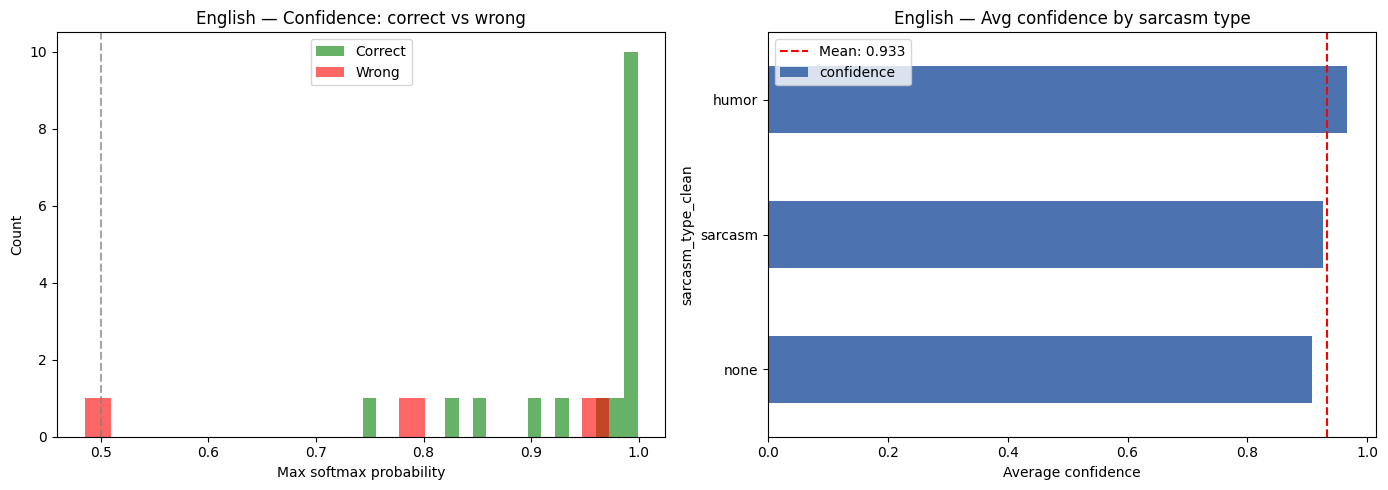


Mean confidence — correct predictions : 0.9509
Mean confidence — wrong predictions   : 0.7498

Low-confidence errors (conf < 0.6): 1
High-confidence errors (conf > 0.9): 1

Sample high-confidence wrong predictions:
  'pope francis donates clothing to needy refugees...'
  Confidence=0.972 | Sarc=sarcasm

Confidence analysis — Bangla


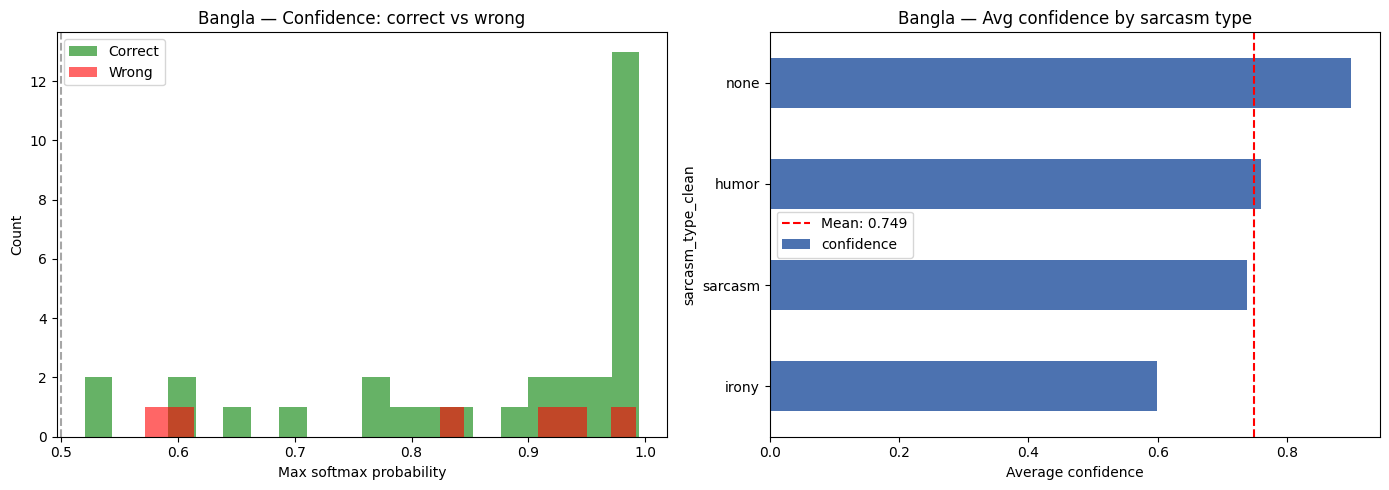


Mean confidence — correct predictions : 0.8711
Mean confidence — wrong predictions   : 0.8126

Low-confidence errors (conf < 0.6): 1
High-confidence errors (conf > 0.9): 3

Sample high-confidence wrong predictions:
  'এই কুলাংগার অমানুষটার দৃষ্টান্তমুলক শাস্তির দাবি জানাই বাংলাদেশ সরকারের কাছে ।...'
  Confidence=0.992 | Sarc=none
  'এরা মুসলিম নামে কলঙ্ক...'
  Confidence=0.918 | Sarc=none
  'সালারে চোরের মত লাগতাছে ।...'
  Confidence=0.949 | Sarc=humor


In [33]:
# ============================================================
#  Model confidence on different annotation types
# ============================================================
def confidence_analysis(df_merged, dataset_name):
    print(f"\n{'='*60}")
    print(f"Confidence analysis — {dataset_name}")
    print(f"{'='*60}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confidence distribution: correct vs wrong
    correct_conf = df_merged[df_merged['correct']]['confidence']
    wrong_conf   = df_merged[~df_merged['correct']]['confidence']

    axes[0].hist(correct_conf, bins=20, alpha=0.6, color='green', label='Correct')
    axes[0].hist(wrong_conf,   bins=20, alpha=0.6, color='red',   label='Wrong')
    axes[0].set_title(f'{dataset_name} — Confidence: correct vs wrong')
    axes[0].set_xlabel('Max softmax probability')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)

    # Confidence by sarcasm type
    sarc_conf = df_merged.groupby('sarcasm_type_clean')['confidence'].mean().sort_values()
    sarc_conf.plot(kind='barh', ax=axes[1], color='#4C72B0')
    axes[1].set_title(f'{dataset_name} — Avg confidence by sarcasm type')
    axes[1].set_xlabel('Average confidence')
    axes[1].axvline(x=sarc_conf.mean(), color='red', linestyle='--',
                    label=f'Mean: {sarc_conf.mean():.3f}')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}confidence_{dataset_name}.png", dpi=150)
    plt.show()

    print(f"\nMean confidence — correct predictions : {correct_conf.mean():.4f}")
    print(f"Mean confidence — wrong predictions   : {wrong_conf.mean():.4f}")

    # Low confidence errors (model uncertain AND wrong — most problematic)
    low_conf_errors = df_merged[(~df_merged['correct']) & (df_merged['confidence'] < 0.6)]
    print(f"\nLow-confidence errors (conf < 0.6): {len(low_conf_errors)}")

    # High confidence errors (model confident BUT wrong — most concerning)
    high_conf_errors = df_merged[(~df_merged['correct']) & (df_merged['confidence'] > 0.9)]
    print(f"High-confidence errors (conf > 0.9): {len(high_conf_errors)}")
    if len(high_conf_errors) > 0:
        print("\nSample high-confidence wrong predictions:")
        for _, row in high_conf_errors.head(3).iterrows():
            print(f"  '{str(row['text'])[:80]}...'")
            print(f"  Confidence={row['confidence']:.3f} | Sarc={row['sarcasm_type_clean']}")

confidence_analysis(en_merged, 'English')
confidence_analysis(bn_merged, 'Bangla')


RQ2 Analysis — English
Which sarcasm subtypes cause the most errors?

Total sarcastic texts in annotated set: 10

Model accuracy per sarcasm subtype:
                    total  accuracy  error_rate
sarcasm_type_clean                             
sarcasm                 8      0.75        0.25
humor                   2      1.00        0.00


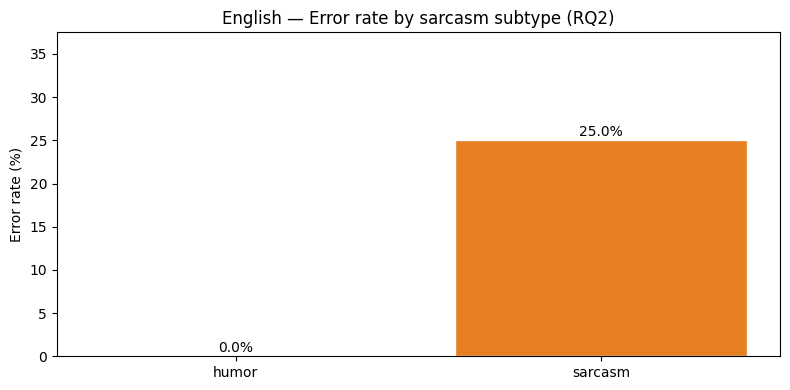


RQ2 Analysis — Bangla
Which sarcasm subtypes cause the most errors?

Total sarcastic texts in annotated set: 8

Model accuracy per sarcasm subtype:
                    total  accuracy  error_rate
sarcasm_type_clean                             
humor                   2       0.0         1.0
irony                   1       1.0         0.0
sarcasm                 5       1.0         0.0


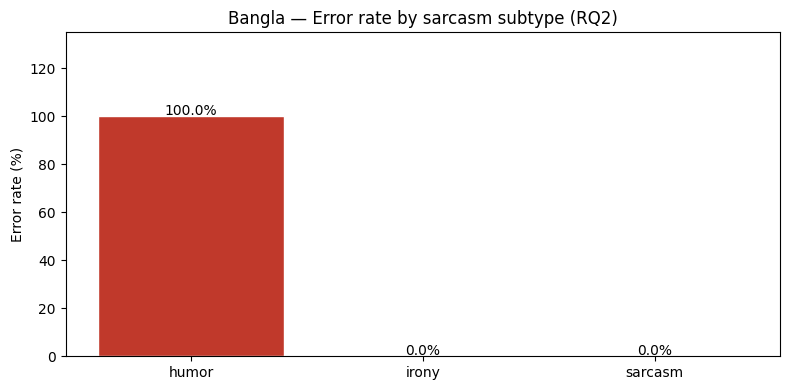

In [34]:
def rq2_analysis(df_merged, dataset_name):
    print(f"\n{'='*60}")
    print(f"RQ2 Analysis — {dataset_name}")
    print(f"Which sarcasm subtypes cause the most errors?")
    print(f"{'='*60}")

    sarc_texts = df_merged[df_merged['is_sarcastic'] == 1].copy()

    if len(sarc_texts) == 0:
        print("No sarcastic texts found in merged set.")
        return

    print(f"\nTotal sarcastic texts in annotated set: {len(sarc_texts)}")

    # Accuracy per sarcasm subtype
    print("\nModel accuracy per sarcasm subtype:")
    subtype_acc = sarc_texts.groupby('sarcasm_type_clean')['correct'].agg(
        ['count','mean']).rename(columns={'count':'total','mean':'accuracy'})
    subtype_acc['error_rate'] = 1 - subtype_acc['accuracy']
    print(subtype_acc.sort_values('error_rate', ascending=False).round(3))

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    subtypes = subtype_acc.index.tolist()
    error_rates = subtype_acc['error_rate'].values * 100
    colors = ['#c0392b' if e > 30 else '#e67e22' if e > 15 else '#27ae60'
              for e in error_rates]
    bars = ax.bar(subtypes, error_rates, color=colors, edgecolor='white')
    for bar, val in zip(bars, error_rates):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}%', ha='center', fontsize=10)
    ax.set_title(f'{dataset_name} — Error rate by sarcasm subtype (RQ2)')
    ax.set_ylabel('Error rate (%)')
    ax.set_ylim(0, max(error_rates)*1.3 + 5)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}rq2_{dataset_name}.png", dpi=150)
    plt.show()

rq2_analysis(en_merged, 'English')
rq2_analysis(bn_merged, 'Bangla')

In [37]:
import re

bn_test['en_word_count'] = bn_test['text_clean'].apply(
    lambda t: len(re.findall(r'[a-zA-Z]{2,}', str(t))))
bn_test['is_codemixed'] = (bn_test['en_word_count'] > 0).astype(int)

total     = len(bn_test)
codemixed = bn_test['is_codemixed'].sum()
print(f"Code-mixed texts in FULL test set: {codemixed}/{total} ({codemixed/total*100:.1f}%)")

cm_acc   = bn_test[bn_test['is_codemixed']==1]['correct'].mean()
pure_acc = bn_test[bn_test['is_codemixed']==0]['correct'].mean()
print(f"Accuracy on code-mixed texts : {cm_acc:.4f}")
print(f"Accuracy on pure Bangla texts: {pure_acc:.4f}")
print(f"Performance gap              : {(pure_acc - cm_acc)*100:.2f} points")

if pure_acc > cm_acc:
    print("→ Code-mixing DEGRADES performance (supports RQ3)")
else:
    print("→ Code-mixing does not degrade performance")

Code-mixed texts in FULL test set: 42/8377 (0.5%)
Accuracy on code-mixed texts : 0.9524
Accuracy on pure Bangla texts: 0.8310
Performance gap              : -12.14 points
→ Code-mixing does not degrade performance



Full test set error analysis — English
Total: 10432 | Correct: 9423 (90.3%) | Errors: 1009 (9.7%)

Per-class accuracy:
  Non-hateful: 85.2% (2955/3470)
  Hateful: 94.1% (3281/3486)
  Sarcastic: 91.7% (3187/3476)

High-confidence errors (conf > 0.9): 318 (3.0% of all test data)
Low-confidence correct  (conf < 0.6): 206


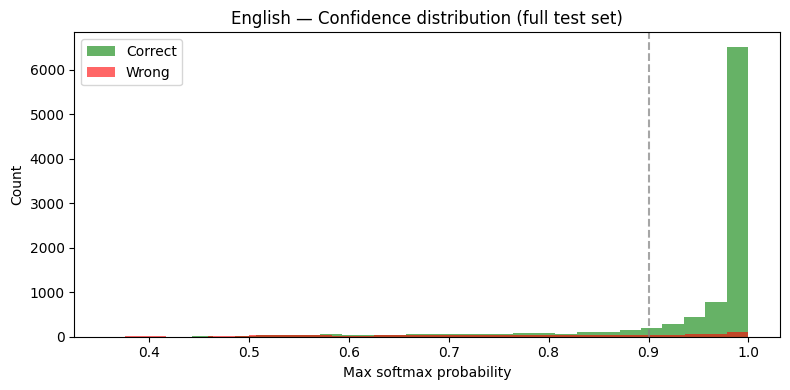


Full test set error analysis — Bangla
Total: 8377 | Correct: 6966 (83.2%) | Errors: 1411 (16.8%)

Per-class accuracy:
  Not Hateful: 79.0% (3271/4140)
  Explicit Hateful: 93.9% (2405/2560)
  Implicit Hateful: 76.9% (1290/1677)

High-confidence errors (conf > 0.9): 229 (2.7% of all test data)
Low-confidence correct  (conf < 0.6): 455


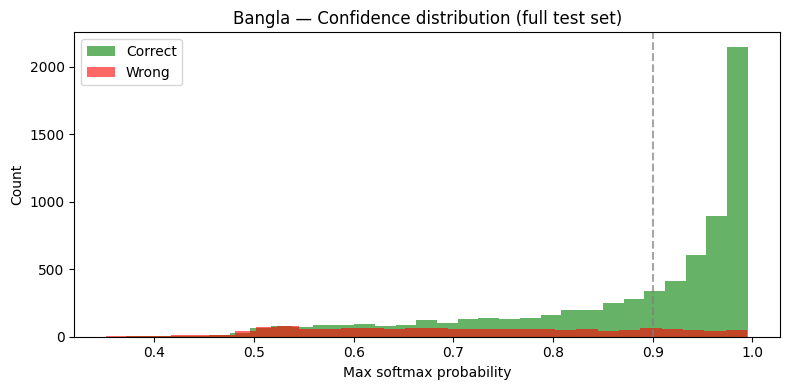

In [38]:

def full_test_error_analysis(df_test, true_col, class_names, dataset_name):
    print(f"\n{'='*60}")
    print(f"Full test set error analysis — {dataset_name}")
    print(f"{'='*60}")

    total   = len(df_test)
    correct = df_test['correct'].sum()
    errors  = df_test[~df_test['correct']]

    print(f"Total: {total} | Correct: {correct} ({correct/total*100:.1f}%) "
          f"| Errors: {len(errors)} ({len(errors)/total*100:.1f}%)")

    # Per-class accuracy
    print("\nPer-class accuracy:")
    for cls, name in class_names.items():
        cls_df  = df_test[df_test[true_col] == cls]
        cls_acc = cls_df['correct'].mean()
        print(f"  {name}: {cls_acc*100:.1f}% ({cls_df['correct'].sum()}/{len(cls_df)})")

    # High confidence errors (model wrong but very sure)
    hce = df_test[(~df_test['correct']) & (df_test['confidence'] > 0.9)]
    print(f"\nHigh-confidence errors (conf > 0.9): {len(hce)} "
          f"({len(hce)/total*100:.1f}% of all test data)")

    # Low confidence correct (model right but unsure)
    lcc = df_test[(df_test['correct']) & (df_test['confidence'] < 0.6)]
    print(f"Low-confidence correct  (conf < 0.6): {len(lcc)}")

    # Confidence distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df_test[df_test['correct']]['confidence'],
            bins=30, alpha=0.6, color='green', label='Correct')
    ax.hist(df_test[~df_test['correct']]['confidence'],
            bins=30, alpha=0.6, color='red',   label='Wrong')
    ax.set_title(f'{dataset_name} — Confidence distribution (full test set)')
    ax.set_xlabel('Max softmax probability')
    ax.set_ylabel('Count')
    ax.legend()
    ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.7, label='0.9 threshold')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}full_test_confidence_{dataset_name}.png", dpi=150)
    plt.show()

full_test_error_analysis(en_test, 'class',  CLASS_NAMES_EN, 'English')
full_test_error_analysis(bn_test, 'label',  CLASS_NAMES_BN, 'Bangla')

In [39]:
# ============================================================
#  Print complete summary for thesis writeup
# ============================================================
print("\n" + "="*70)
print("COMPLETE SUMMARY ")
print("="*70)

print("\n--- ANNOTATION STATISTICS ---")
print(f"English annotated: {len(en)} texts  "
      f"| Classes: {en['original_label'].value_counts().to_dict()}")
print(f"Bangla  annotated: {len(bn)} texts  "
      f"| Classes: {bn['label'].value_counts().to_dict()}")

print(f"\nEnglish sarcasm subtypes: {en[en['is_sarcastic']==1]['sarcasm_type_clean'].value_counts().to_dict()}")
print(f"Bangla  sarcasm subtypes: {bn[bn['is_sarcastic']==1]['sarcasm_type_clean'].value_counts().to_dict()}")

print(f"\nEnglish sarcastic+hateful: {((en['is_sarcastic']==1)&(en['is_hateful']==1)).sum()} "
      f"({((en['is_sarcastic']==1)&(en['is_hateful']==1)).sum()/len(en)*100:.1f}%)")
print(f"Bangla  sarcastic+hateful: {((bn['is_sarcastic']==1)&(bn['is_hateful']==1)).sum()} "
      f"({((bn['is_sarcastic']==1)&(bn['is_hateful']==1)).sum()/len(bn)*100:.1f}%)")

print("\n--- MODEL PERFORMANCE (TEST SET) ---")
print(f"BERT English:       Acc={en_test['correct'].mean():.4f}")
print(f"BanglaBERT Bangla:  Acc={bn_test['correct'].mean():.4f}")

if len(en_merged) > 0:
    print(f"\nBERT on annotated subset:       Acc={en_merged['correct'].mean():.4f}")
if len(bn_merged) > 0:
    print(f"BanglaBERT on annotated subset: Acc={bn_merged['correct'].mean():.4f}")


COMPLETE SUMMARY 

--- ANNOTATION STATISTICS ---
English annotated: 999 texts  | Classes: {0: 340, 1: 336, 2: 323}
Bangla  annotated: 999 texts  | Classes: {1: 333, 2: 333, 0: 333}

English sarcasm subtypes: {'sarcasm': 205, 'humor': 87, 'irony': 21, 'metaphor': 5}
Bangla  sarcasm subtypes: {'sarcasm': 196, 'humor': 84, 'irony': 37, 'metaphor': 5}

English sarcastic+hateful: 8 (0.8%)
Bangla  sarcastic+hateful: 17 (1.7%)

--- MODEL PERFORMANCE (TEST SET) ---
BERT English:       Acc=0.9033
BanglaBERT Bangla:  Acc=0.8316

BERT on annotated subset:       Acc=0.8500
BanglaBERT on annotated subset: Acc=0.8378
